## This file contains code for our regression analysis

In [3]:
# import necessary packages 
import pandas as pd 
import numpy as np 
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [12]:
# load data 
demographic_abcs = pd.read_csv('../data/demographic_abcs.csv')

In [13]:

# filter to type of service and drop missing 
def preprocess_data(df, columns_of_interest, service_map):
    df_filtered = df[columns_of_interest]
    df_filtered['Type of Service'] = df_filtered['Type of Service'].map(service_map)
    return df_filtered.dropna()


# regression 
def run_ols_regression(df, rename_dict):
    X = df['Type of Service']
    y = df.iloc[:, 1:]
    X = sm.add_constant(X)
    
    coefficients = []
    std_errors = []
    means = y.mean()

    for col in y.columns:
        model = sm.OLS(y[col], X).fit()
        coefficients.append(model.params['Type of Service'] / means[col] * 100)
        std_errors.append(model.bse['Type of Service'] / means[col] * 100)
        print(f"Regression results for {col}:")
        print(model.summary())

    return coefficients, std_errors, y.columns

# show plot organized by percent change effect 
def plot_results(coefficients, std_errors, labels, rename_dict, output_path):
    sorted_indices = np.argsort(coefficients)
    sorted_coefficients = np.array(coefficients)[sorted_indices]
    sorted_std_errors = np.array(std_errors)[sorted_indices]
    sorted_labels = [rename_dict[labels[i]] for i in sorted_indices]

    plt.figure(figsize=(10, 6))
    plt.errorbar(range(len(sorted_labels)), sorted_coefficients, yerr=sorted_std_errors, fmt='o', capsize=5, color='teal')
    plt.xticks(range(len(sorted_labels)), sorted_labels)
    plt.xlabel('Normalized ABC Score', fontsize=12, fontweight='bold')
    plt.ylabel('Percent Change in Mean ABC Score post-intake', fontsize=10, fontweight='bold')
    plt.title('Percent Change in ABC Score, Transition from Intake to Re-Evaluation', fontsize=16, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()


In [15]:
# dictionary with labels for each ABC score 
rename_dict = {
    'norm_hyper': 'Hyperactivity',
    'norm_ir_agit': 'Irritability/Agitation',
    'norm_leth_soc': 'Lethargy/Social Withdrawal',
    'norm_speech': 'Speech Issues',
    'norm_stereo': 'Stereotypy'
}

In [16]:
columns_of_interest = ['Type of Service', 'norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']
service_map = {'Intake': 0, 'Re-evaluation': 1}

df_analysis = preprocess_data(demographic_abcs, columns_of_interest, service_map)
coefficients, std_errors, labels = run_ols_regression(df_analysis, rename_dict)

Regression results for norm_leth_soc:
                            OLS Regression Results                            
Dep. Variable:          norm_leth_soc   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     544.7
Date:                Sat, 01 Jun 2024   Prob (F-statistic):          8.00e-119
Time:                        20:09:15   Log-Likelihood:                -82653.
No. Observations:               19226   AIC:                         1.653e+05
Df Residuals:                   19224   BIC:                         1.653e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
cons

/var/folders/bw/cm4d5pyn7ns9dsb22kh7m9bc0000gn/T/ipykernel_89891/918045505.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Type of Service'] = df_filtered['Type of Service'].map(service_map)


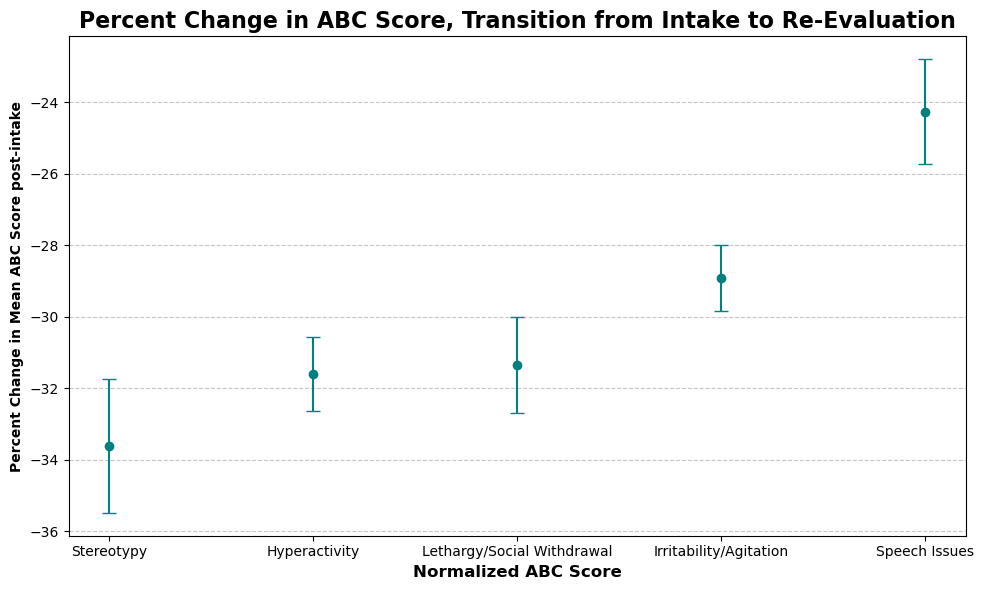

In [17]:
plot_results(coefficients, std_errors, labels, rename_dict, "../output/ols_regression.png")
